# Phase 2: Script and Sound Weights

This notebook computes weighted confusion edges for phonemes and graphemes (alphabet/abugida layers) from the Phase 1 graph. It incorporates string/IPA similarity as well as manual seed confusion tables, exporting the results to CSV and a new weighted GraphML.

In [28]:
import networkx as nx
import pandas as pd
import os
import matplotlib.pyplot as plt
import json
import itertools
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

try:
    import Levenshtein
    def string_distance(a, b):
        return Levenshtein.distance(a, b)
except ImportError:
    import difflib
    def string_distance(a, b):
        # Fallback to difflib
        matcher = difflib.SequenceMatcher(None, a, b)
        return int((1 - matcher.ratio()) * max(len(a), len(b)))

def normalized_similarity(a, b):
    if not a or not b: return 0.0
    dist = string_distance(a, b)
    max_len = max(len(a), len(b))
    if max_len == 0: return 1.0
    return max(0.0, 1.0 - (dist / max_len))


In [29]:
# Configuration
GRAPH_PATH = 'artifacts/graph.graphml'
OUTPUT_PHONEME_CSV = 'artifacts/phoneme_confusion_weights.csv'
OUTPUT_GRAPHEME_CSV = 'artifacts/grapheme_confusion_weights.csv'
OUTPUT_GRAPH_PATH = 'artifacts/graph_phase2_scriptweights.graphml'

LANGUAGES = ['np', 'ur', 'vn', 'dr']
PHONEME_CONFUSION_THRESHOLD = 0.35
GRAPHEME_CONFUSION_THRESHOLD = 0.30

# Seed config
SEED_DIR = 'data/seeds'


In [30]:
print("Loading GraphML...")
G = nx.read_graphml(GRAPH_PATH)
print(f"Loaded {len(G.nodes)} nodes and {len(G.edges)} edges.")


Loading GraphML...
Loaded 290518 nodes and 307013 edges.


In [31]:
def get_nodes_by_type_and_language(G, ntype, lang):
    nodes = []
    for n, data in G.nodes(data=True):
        if data.get('type') == ntype and data.get('language') == lang:
            nodes.append((n, data))
    return nodes

# Example counts
for lang in LANGUAGES:
    p_nodes = get_nodes_by_type_and_language(G, 'Phoneme', lang)
    g_nodes = get_nodes_by_type_and_language(G, 'Grapheme', lang)
    print(f"Language: {lang} | Phonemes: {len(p_nodes)}, Graphemes: {len(g_nodes)}")


Language: np | Phonemes: 49, Graphemes: 53
Language: ur | Phonemes: 31, Graphemes: 39
Language: vn | Phonemes: 82, Graphemes: 178
Language: dr | Phonemes: 32, Graphemes: 67


In [32]:
def compute_phoneme_confusion_score(G, n_a, d_a, n_b, d_b):
    if n_a == n_b: return 0.0, {}
    
    ipa_a = d_a.get('ipa', '').replace('/', '')
    ipa_b = d_b.get('ipa', '').replace('/', '')
    
    # 1. IPA Similarity
    ipa_sim = normalized_similarity(ipa_a, ipa_b)
    
    # Simple length penalty
    len_diff = abs(len(ipa_a) - len(ipa_b))
    length_penalty = 0.05 * len_diff
    
    # Example Weighting (can be adjusted)
    # 0.8 from IPA similarity
    score = (0.8 * ipa_sim) - length_penalty
    score = max(0.0, min(1.0, score))
    
    components = {'ipa_sim': round(ipa_sim, 3), 'len_diff': len_diff}
    return score, components

def compute_grapheme_confusion_score(G, n_a, d_a, n_b, d_b):
    if n_a == n_b: return 0.0, {}
    
    char_a = d_a.get('char', '')
    char_b = d_b.get('char', '')
    
    # 1. Unicode/String Similarity
    char_sim = normalized_similarity(char_a, char_b)
    
    score = char_sim
    score = max(0.0, min(1.0, score))
    
    components = {'char_sim': round(char_sim, 3)}
    return score, components


In [33]:
def build_confusion_table(G, ntype, languages, threshold, scoring_func):
    records = []
    for lang in languages:
        nodes = get_nodes_by_type_and_language(G, ntype, lang)
        
        # All pairs
        for (n_a, d_a), (n_b, d_b) in itertools.permutations(nodes, 2):
            score, components = scoring_func(G, n_a, d_a, n_b, d_b)
            if score >= threshold:
                rel = 'confusable_with' if ntype == 'Phoneme' else 'visually_confusable_with'
                records.append({
                    'source': n_a,
                    'target': n_b,
                    'language': lang,
                    'relation': rel,
                    'weight': round(score, 3),
                    'score_components': json.dumps(components),
                    'method': 'automatic_only'
                })
    return pd.DataFrame(records)

print("Computing auto phoneme confusions...")
df_phoneme_auto = build_confusion_table(G, 'Phoneme', LANGUAGES, PHONEME_CONFUSION_THRESHOLD, compute_phoneme_confusion_score)
print(f"Generated {len(df_phoneme_auto)} auto phoneme pairs.")

print("Computing auto grapheme confusions...")
df_grapheme_auto = build_confusion_table(G, 'Grapheme', LANGUAGES, GRAPHEME_CONFUSION_THRESHOLD, compute_grapheme_confusion_score)
print(f"Generated {len(df_grapheme_auto)} auto grapheme pairs.")


Computing auto phoneme confusions...
Generated 3518 auto phoneme pairs.
Computing auto grapheme confusions...
Generated 1262 auto grapheme pairs.


In [34]:
def load_and_merge_seeds(df_auto, ntype):
    # ntype lowercase
    ntype_lower = ntype.lower()
    
    merged_records = df_auto.to_dict('records') if not df_auto.empty else []
    auto_dict = {(r['source'], r['target'], r['language']): r for r in merged_records}
    
    for lang in LANGUAGES:
        seed_file = os.path.join(SEED_DIR, f'manual_{ntype_lower}_confusions_{lang}.csv')
        if not os.path.exists(seed_file):
            continue
            
        print(f"Loading seeds from {seed_file}...")
        df_seed = pd.read_csv(seed_file)
        
        for _, row in df_seed.iterrows():
            src = row['source']
            tgt = row['target']
            seed_lang = row['language']
            seed_wt = float(row['seed_weight'])
            reason = row.get('reason', '')
            
            # verify nodes exist
            if src not in G or tgt not in G:
                print(f"Warning: Seed node not found in graph ({src} or {tgt})")
                continue
                
            key = (src, tgt, seed_lang)
            rel = 'confusable_with' if ntype == 'Phoneme' else 'visually_confusable_with'
            
            if key in auto_dict:
                auto_wt = auto_dict[key]['weight']
                final_wt = max(auto_wt, seed_wt)
                auto_dict[key]['weight'] = final_wt
                auto_dict[key]['method'] = 'automatic_plus_manual'
                comps = json.loads(auto_dict[key].get('score_components', '{}'))
                comps['seed_reason'] = reason
                comps['seed_weight'] = seed_wt
                auto_dict[key]['score_components'] = json.dumps(comps)
            else:
                auto_dict[key] = {
                    'source': src,
                    'target': tgt,
                    'language': seed_lang,
                    'relation': rel,
                    'weight': seed_wt,
                    'score_components': json.dumps({'seed_reason': reason, 'seed_weight': seed_wt}),
                    'method': 'manual_only'
                }
                
    return pd.DataFrame(list(auto_dict.values()))

df_phoneme_final = load_and_merge_seeds(df_phoneme_auto, 'Phoneme')
df_grapheme_final = load_and_merge_seeds(df_grapheme_auto, 'Grapheme')

print(f"Final phoneme pairs: {len(df_phoneme_final)}")
print(f"Final grapheme pairs: {len(df_grapheme_final)}")


Loading seeds from data/seeds/manual_phoneme_confusions_np.csv...
Loading seeds from data/seeds/manual_phoneme_confusions_ur.csv...
Loading seeds from data/seeds/manual_phoneme_confusions_vn.csv...
Loading seeds from data/seeds/manual_phoneme_confusions_dr.csv...
Loading seeds from data/seeds/manual_grapheme_confusions_np.csv...
Loading seeds from data/seeds/manual_grapheme_confusions_ur.csv...
Loading seeds from data/seeds/manual_grapheme_confusions_vn.csv...
Loading seeds from data/seeds/manual_grapheme_confusions_dr.csv...
Final phoneme pairs: 3528
Final grapheme pairs: 1316


In [35]:
df_phoneme_final.to_csv(OUTPUT_PHONEME_CSV, index=False)
df_grapheme_final.to_csv(OUTPUT_GRAPHEME_CSV, index=False)
print("Saved CSVs.")


Saved CSVs.


In [36]:
def attach_edges(G, df):
    count = 0
    for _, row in df.iterrows():
        src = row['source']
        tgt = row['target']
        G.add_edge(src, tgt, 
                   relation=row['relation'],
                   weight=row['weight'],
                   language=row['language'],
                   method=row['method'],
                   score_components=row['score_components'])
        count += 1
    return count

print("Attaching phoneme edges...")
p_count = attach_edges(G, df_phoneme_final)
print("Attaching grapheme edges...")
g_count = attach_edges(G, df_grapheme_final)
print(f"Attached {p_count} phoneme edges and {g_count} grapheme edges.")


Attaching phoneme edges...
Attaching grapheme edges...
Attached 3528 phoneme edges and 1316 grapheme edges.


In [37]:
def validate_confusion_edges(G):
    # check no self-loops with these relations
    # check no cross-language edges
    # check weights bounds
    rels = {'confusable_with', 'visually_confusable_with'}
    
    for u, v, d in G.edges(data=True):
        if d.get('relation') in rels:
            assert u != v, f"Self-loop found on {u}"
            u_lang = G.nodes[u].get('language')
            v_lang = G.nodes[v].get('language')
            assert u_lang == v_lang, f"Cross-language edge {u} -> {v}"
            wt = d.get('weight', 0)
            assert 0 <= wt <= 1, f"Weight out of bounds on {u}->{v}: {wt}"
            
    print("Validation passed: No self-loops, no cross-language, bounded weights.")
    
validate_confusion_edges(G)


Validation passed: No self-loops, no cross-language, bounded weights.


In [40]:
def inspect_confusions(G, node_id, top_n=10):
    if node_id not in G:
        print("Node not found.")
        return
        
    print(f"Top confusions for {node_id}:")
    edges = [(v, d) for u, v, d in G.out_edges(node_id, data=True) if d.get('relation') in ['confusable_with', 'visually_confusable_with']]
    edges = sorted(edges, key=lambda x: x[1].get('weight', 0), reverse=True)
    
    for v, d in edges[:top_n]:
        print(f"  -> {v} | Weight: {d.get('weight')} | Method: {d.get('method')}")

# Examples
print("\n--- Nepali Grapheme Inspection ---")
inspect_confusions(G, 'grapheme:np:भ')

print("\n--- Nepali Phoneme Inspection ---")
inspect_confusions(G, 'phoneme:np:/kʌ/')



--- Nepali Grapheme Inspection ---
Top confusions for grapheme:np:भ:
  -> grapheme:np:म | Weight: 0.9 | Method: manual_only

--- Nepali Phoneme Inspection ---
Top confusions for phoneme:np:/kʌ/:
  -> phoneme:np:/ʌ/ | Weight: 0.75 | Method: automatic_only
  -> phoneme:np:/kʰʌ/ | Weight: 0.75 | Method: automatic_only
  -> phoneme:np:/ksʌ/ | Weight: 0.75 | Method: automatic_only
  -> phoneme:np:/ʌhʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/ɡʱʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/tsʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/dzʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/ʈʰʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/ɖʱʌ/ | Weight: 0.483 | Method: automatic_only
  -> phoneme:np:/tʰʌ/ | Weight: 0.483 | Method: automatic_only


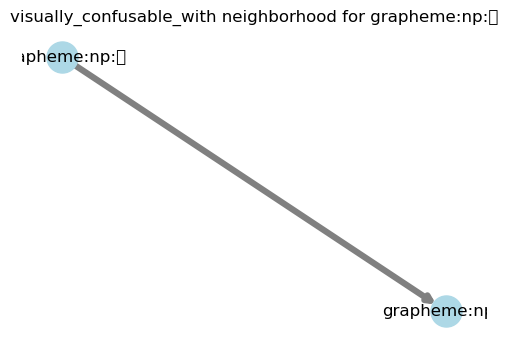

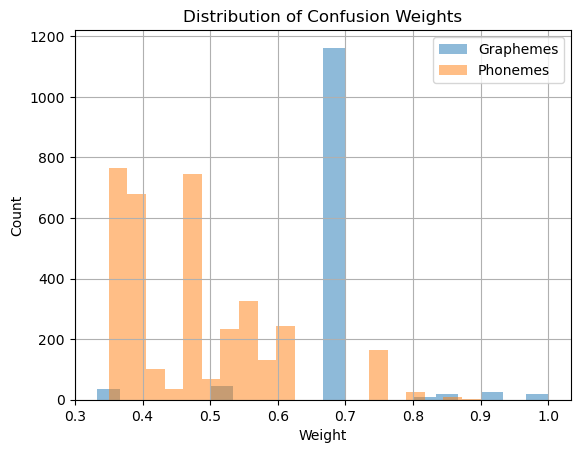

In [41]:
def plot_confusion_neighborhood(G, node_id, relation, top_n=8):
    if node_id not in G: return
    
    edges = [(u, v, d) for u, v, d in G.out_edges(node_id, data=True) if d.get('relation') == relation]
    edges = sorted(edges, key=lambda x: x[2].get('weight', 0), reverse=True)[:top_n]
    
    if not edges:
        print(f"No edges found for {node_id} with relation {relation}")
        return
        
    subgraph_nodes = set([node_id] + [v for u, v, d in edges])
    H = G.subgraph(subgraph_nodes)
    
    plt.figure(figsize=(6, 4))
    pos = nx.spring_layout(H, seed=42)
    
    nx.draw_networkx_nodes(H, pos, node_color='lightblue', node_size=500)
    nx.draw_networkx_labels(H, pos)
    
    # Draw edges
    weights = [d.get('weight', 0.5) * 5 for u, v, d in edges]
    nx.draw_networkx_edges(H, pos, edgelist=[(u,v) for u,v,d in edges], width=weights, edge_color='gray')
    
    plt.title(f"{relation} neighborhood for {node_id}")
    plt.axis('off')
    plt.show()

plot_confusion_neighborhood(G, 'grapheme:np:भ', 'visually_confusable_with')

# Histogram
df_grapheme_final['weight'].hist(alpha=0.5, label='Graphemes', bins=20)
if not df_phoneme_final.empty:
    df_phoneme_final['weight'].hist(alpha=0.5, label='Phonemes', bins=20)
plt.title('Distribution of Confusion Weights')
plt.xlabel('Weight')
plt.ylabel('Count')
plt.legend()
plt.show()


In [42]:
print(f"Exporting updated GraphML to {OUTPUT_GRAPH_PATH}...")
nx.write_graphml(G, OUTPUT_GRAPH_PATH)
print("Done!")


Exporting updated GraphML to artifacts/graph_phase2_scriptweights.graphml...
Done!
